# Bridge: Attention and Transformers — Just Enough to Use Them

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain attention as a **weighted average**, where the weights come from vector similarity
- Compute scaled dot-product self-attention by hand in NumPy and read an attention-weight heatmap
- See why word order needs **positional encodings**, and what a **causal (GPT-style) mask** changes
- Place **BERT** and **GPT** on the transformer map, so the rest of this unit can use them as pretrained models

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4 (neurons, weights, layers) and Course 07 — Unit 2, lesson 02 (word vectors): attention is a weighted average of those vectors, with weights from vector similarity.

**Used later in:** Course 07 — Unit 4, lessons 03-05 (BERT, seq2seq, GPT) and Course 08 (AIAT 122) — Unit 3, which trains transformers rather than using them pretrained.

## ⚠️ Why this notebook exists

In the diploma's official order, this NLP course (AIAT 121) comes **before** the Deep Learning course (AIAT 122).
The rest of this unit uses transformer models (BERT, GPT) as **pretrained black boxes** — models someone else
already trained. This notebook gives you just enough intuition about **attention**, the mechanism inside those
boxes, to use them with understanding. The full mechanics — training transformers, backpropagation, building
them in PyTorch/TensorFlow — arrive in **AIAT 122 (Course 08, Deep Learning)**.


## 🌍 Why this matters: the year Google Translate got noticeably better

In 2016 Google replaced the phrase-based statistical engine behind Google Translate with a neural
encoder–decoder built on **attention**. The system paper (Wu et al., *Google's Neural Machine Translation
System*, [arXiv:1609.08144](https://arxiv.org/abs/1609.08144)) describes a network of "8 encoder and 8
decoder layers using attention and residual connections", and reports that it **reduces translation errors
by an average of 60% compared to Google's phrase-based production system**. Users noticed the difference
without being told. One year later *Attention Is All You Need*
([arXiv:1706.03762](https://arxiv.org/abs/1706.03762)) threw away the recurrent layers and kept only the
attention — and that architecture is what BERT, GPT and every model in the rest of this unit are made of.

**What goes wrong without this mechanism.** Before attention, an encoder–decoder squeezed the entire source
sentence into one fixed-length vector and the decoder had to write the whole translation from that alone.
Bahdanau, Cho & Bengio named the problem in their abstract: *"we conjecture that the use of a fixed-length
vector is a bottleneck in improving the performance of this basic encoder-decoder architecture"*
([arXiv:1409.0473](https://arxiv.org/abs/1409.0473)). Attention removes the bottleneck by letting every
position look back at every other position directly.

In this notebook you compute that look-back yourself, and watch the pronoun **"it"** find **"animal"** —
with no rule about pronouns anywhere in the code. That is the whole trick: the connection falls out of
vector similarity.

## 📥 Inputs & 📤 Outputs

**Inputs:** a toy 9-word sentence and small hand-crafted word vectors (defined in this notebook — no downloads, no training).

**Outputs:** attention-weight tables and heatmaps computed live in NumPy, a positional-encoding visual, and a causal-mask visual.

---


## Part 1: Words as Vectors (recap)

In Unit 2 you saw that NLP models represent each word as a **vector of numbers**, and that similar words get
similar vectors. We will reuse that idea with a tiny hand-made vocabulary.

Our toy sentence:

> *"the animal crossed the street because **it** was tired"*

The interesting question: when the model reads **"it"**, which earlier word should "it" be connected to?
A human knows "it" = the animal (streets do not get tired). Attention is the mechanism that lets a model
make exactly this kind of connection.

**Honesty note:** the 4-number vectors below are **hand-crafted** so the arithmetic is easy to follow — each
dimension has a readable meaning (animal-ness, road-ness, action-ness, grammar-word-ness). In a real
transformer these vectors are **learned from data** and have hundreds of dimensions with no human-readable
meaning. The *mechanism* we compute with them is exactly the real one.


In [1]:
# Set the stage: a 9-word sentence and hand-crafted 4-dimensional word vectors.
# Real models LEARN embeddings with hundreds of dimensions; ours are tiny and
# human-readable so you can trace every attention number by hand.

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

words = ["the", "animal", "crossed", "the", "street", "because", "it", "was", "tired"]

# Hand-crafted 4-dimensional word vectors.
# Dimensions:            [animal-ness, road-ness, action-ness, grammar-word-ness]
vectors = {
    "the":     [0.0, 0.0, 0.0, 3.0],
    "animal":  [3.0, 0.0, 0.6, 0.0],
    "crossed": [0.6, 0.6, 3.0, 0.0],
    "street":  [0.0, 3.0, 0.0, 0.0],
    "because": [0.0, 0.0, 0.0, 3.0],
    "it":      [2.4, 0.3, 0.0, 0.6],   # a pronoun; in this sentence it refers to something animal-like
    "was":     [0.0, 0.0, 0.9, 2.4],
    "tired":   [2.1, 0.0, 0.9, 0.0],   # a state of living things -> high animal-ness
}

# Embedding matrix: one row per word IN SENTENCE ORDER (9 rows x 4 dims)
E = np.array([vectors[w] for w in words])

print(f"Sentence: {' '.join(words)}")
print(f"Embedding matrix shape: {E.shape}  (9 words x 4 dimensions)\n")
print(f"{'word':10s} {'animal':>7s} {'road':>7s} {'action':>7s} {'grammar':>8s}")
print("-" * 44)
for w, row in zip(words, E):
    print(f"{w:10s} {row[0]:7.1f} {row[1]:7.1f} {row[2]:7.1f} {row[3]:8.1f}")

Sentence: the animal crossed the street because it was tired
Embedding matrix shape: (9, 4)  (9 words x 4 dimensions)

word        animal    road  action  grammar
--------------------------------------------
the            0.0     0.0     0.0      3.0
animal         3.0     0.0     0.6      0.0
crossed        0.6     0.6     3.0      0.0
the            0.0     0.0     0.0      3.0
street         0.0     3.0     0.0      0.0
because        0.0     0.0     0.0      3.0
it             2.4     0.3     0.0      0.6
was            0.0     0.0     0.9      2.4
tired          2.1     0.0     0.9      0.0


## Part 2: Attention Is a Weighted Average

An RNN (next notebook) squeezes a whole sentence into **one** hidden vector, which struggles with long
sentences. Attention takes a different route: every word gets to **look at every other word directly** and
build its output as a *weighted average* of them.

For each word (the **query**), against every word in the sentence (the **keys**):

1. **Score** — how relevant is that word to me? `score = (query · key) / sqrt(d)`
   (a dot product: large when the vectors point the same way; divided by `sqrt(d)` to keep numbers tame)
2. **Weights** — turn scores into percentages with a **softmax** (all weights ≥ 0, each row sums to 1)
3. **Output** — a weighted average of all the word vectors (the **values**): `output = Σ weight_i × value_i`

That is the entire core formula of a transformer: `Attention(Q, K, V) = softmax(QKᵀ / √d) · V`.

In a real transformer, Q, K, and V are three different *learned* projections of the embeddings. To keep the
arithmetic transparent we use the embeddings themselves for all three (that special case is still genuine
self-attention — just without the learned projections).


In [2]:
# Compute self-attention from scratch: scores -> softmax -> weighted average.
# This is the core transformer equation. Watch the pronoun 'it' figure out,
# from vector similarity alone, that it refers to 'animal'.

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)   # numerical stability
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

d = E.shape[1]                      # vector dimension (4)
scores = E @ E.T / np.sqrt(d)       # step 1: all query-key dot products (9x9)
attn = softmax(scores, axis=1)      # step 2: each row -> percentages summing to 1

print(f"Attention matrix shape: {attn.shape} (rows = queries, columns = keys)")
print(f"Every row sums to 1: {np.allclose(attn.sum(axis=1), 1.0)}\n")

# Focus on the row for the pronoun "it"
i_it = words.index("it")
order = np.argsort(attn[i_it])[::-1]

print("Where does 'it' put its attention?")
print("-" * 34)
for j in order:
    bar = "#" * int(round(attn[i_it, j] * 50))
    print(f"  {words[j]:10s} {attn[i_it, j]:5.1%}  {bar}")

top = order[0]
print(f"\nComputed result: 'it' attends most strongly to '{words[top]}' "
      f"({attn[i_it, top]:.1%} of its attention).")

# Step 3: the output for 'it' is a weighted average of ALL word vectors
out_it = attn[i_it] @ E
print(f"\nOriginal vector for 'it':          {E[i_it]}")
print(f"Attention output for 'it':         {out_it}")
print("The output vector for 'it' has been pulled toward the words it attends to —")
print("context is now mixed into the representation. That is attention's whole job.")

Attention matrix shape: (9, 9) (rows = queries, columns = keys)
Every row sums to 1: True

Where does 'it' put its attention?
----------------------------------
  animal     43.3%  ######################
  it         26.4%  #############
  tired      14.7%  #######
  because     2.9%  #
  the         2.9%  #
  the         2.9%  #
  crossed     2.7%  #
  was         2.4%  #
  street      1.9%  #

Computed result: 'it' attends most strongly to 'animal' (43.3% of its attention).

Original vector for 'it':          [2.4 0.3 0.  0.6]
Attention output for 'it':         [2.256 0.151 0.493 0.478]
The output vector for 'it' has been pulled toward the words it attends to —
context is now mixed into the representation. That is attention's whole job.


## Part 3: Reading an Attention Map

Doing this for **all** words at once gives a 9×9 matrix of weights — the **attention map**. Each **row** is
one word's attention budget (rows sum to 100%). These maps are how researchers peek inside transformers.


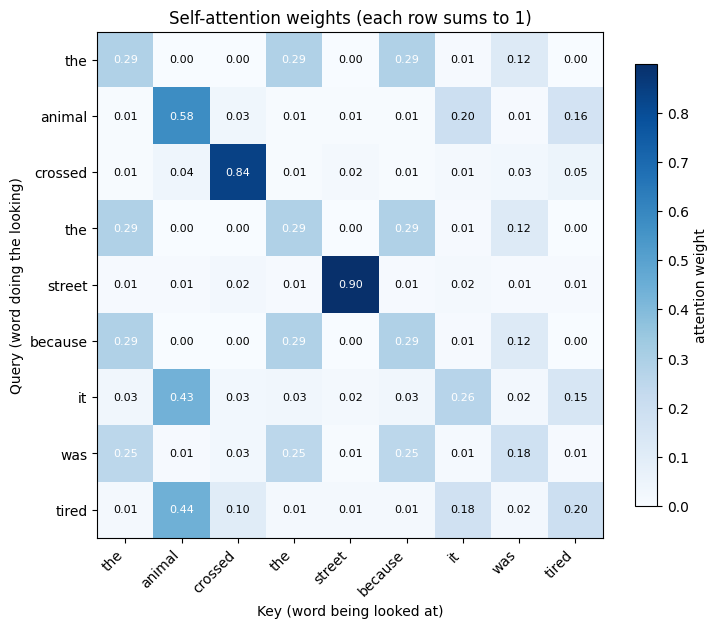

Top attention target for each word (computed from the matrix above):
  the        -> the        (28.7%)
  animal     -> animal     (57.8%)
  crossed    -> crossed    (83.8%)
  the        -> the        (28.7%)
  street     -> street     (90.0%)
  because    -> the        (28.7%)
  it         -> animal     (43.3%)
  was        -> the        (25.0%)
  tired      -> animal     (44.1%)


In [3]:
# Draw the full 9x9 attention heatmap — every query row, every key column.
# Heatmaps are how researchers inspect attention: darker cell = more attention.
# Check the 'it' row here against the numbers printed in the previous cell.

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(attn, cmap="Blues", vmin=0)
ax.set_xticks(range(len(words)), words, rotation=45, ha="right")
ax.set_yticks(range(len(words)), words)
ax.set_xlabel("Key (word being looked at)")
ax.set_ylabel("Query (word doing the looking)")
ax.set_title("Self-attention weights (each row sums to 1)")
# Write the numeric weight inside each cell so the map can be read exactly.
for r in range(len(words)):
    for c in range(len(words)):
        ax.text(c, r, f"{attn[r, c]:.2f}", ha="center", va="center",
                color="white" if attn[r, c] > 0.25 else "black", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8, label="attention weight")
plt.tight_layout()
plt.show()

# Reduce each row to its strongest link — a one-line summary of the heatmap.
print("Top attention target for each word (computed from the matrix above):")
for r, w in enumerate(words):
    c = int(np.argmax(attn[r]))
    print(f"  {w:10s} -> {words[c]:10s} ({attn[r, c]:.1%})")

Notice in the map (all of this is computed, not asserted — check the printed list against the heatmap):

- **"it"** spends most of its budget on **"animal"** — the pronoun connection we wanted.
- **"tired"** also leans toward **"animal"** (only living things get tired in our toy features).
- Grammar words (**"the"**, **"because"**) mostly attend to each other — they share the grammar dimension.

## Part 4: Multiple Heads — Different Questions at Once

One attention map can only capture one *kind* of relationship. Real transformers run many attention maps in
parallel — called **heads** — each with its own learned projections, so each head can specialize (one might
track pronoun references, another verb–subject links, another nearby words).

We can imitate that with our toy vectors: give one head only the **semantic** dimensions (animal-ness,
road-ness) and another head only the **grammar** dimensions (action-ness, grammar-word-ness).


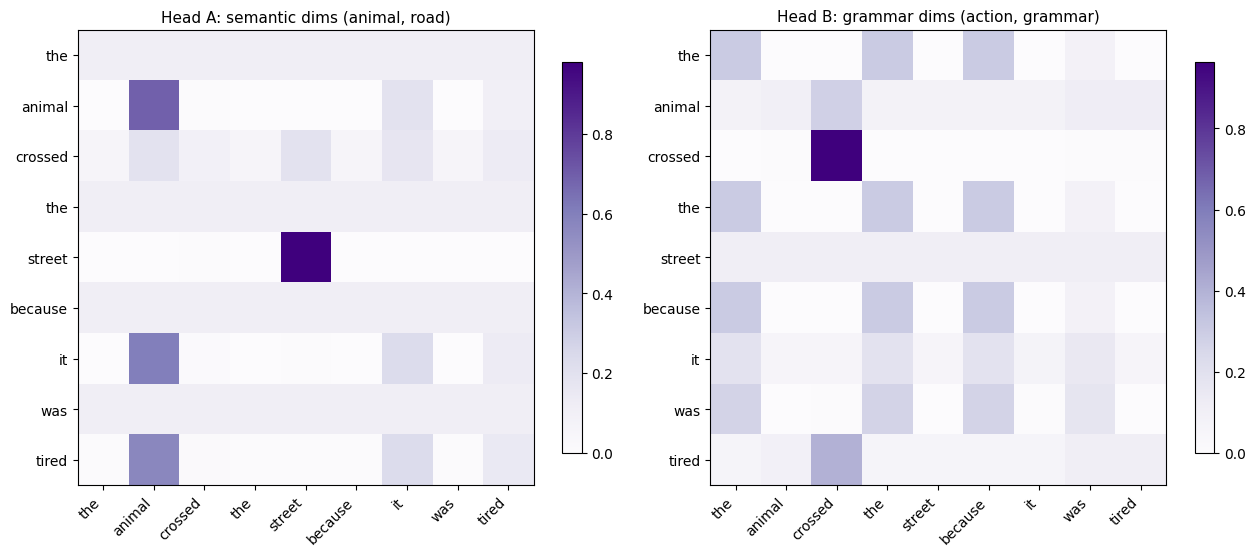

Head A: semantic dims (animal, road): 'it' attends most to 'animal' (60.3%)
Head B: grammar dims (action, grammar): 'it' attends most to 'the' (19.0%)

Different heads, different attention patterns -> the model captures several
kinds of relationships at once. Real models use 8-16+ learned heads per layer.


In [4]:
# Simulate multi-head attention: run attention separately on two halves of each vector.
# Head A sees only the semantic dimensions, Head B only the grammar dimensions —
# each head finds a DIFFERENT pattern in the same sentence. That is why heads exist.

heads = {
    "Head A: semantic dims (animal, road)": E[:, 0:2],
    "Head B: grammar dims (action, grammar)": E[:, 2:4],
}

# Side-by-side heatmaps: one attention pattern per head.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
head_maps = {}
for ax, (name, Eh) in zip(axes, heads.items()):
    A = softmax(Eh @ Eh.T / np.sqrt(Eh.shape[1]), axis=1)
    head_maps[name] = A
    im = ax.imshow(A, cmap="Purples", vmin=0)
    ax.set_xticks(range(len(words)), words, rotation=45, ha="right")
    ax.set_yticks(range(len(words)), words)
    ax.set_title(name, fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Report where 'it' looks under each head — the two answers differ.
for name, A in head_maps.items():
    i = words.index("it")
    j = int(np.argmax(A[i]))
    print(f"{name}: 'it' attends most to '{words[j]}' ({A[i, j]:.1%})")
print("\nDifferent heads, different attention patterns -> the model captures several")
print("kinds of relationships at once. Real models use 8-16+ learned heads per layer.")

## Part 5: Word Order — Positional Encodings

Look back at the attention formula: it only uses dot products between word vectors. Shuffle the sentence and
each word's attention weights just get shuffled with it — attention by itself is **order-blind** (it sees a
*bag* of vectors). But *"dog bites man"* ≠ *"man bites dog"*!

Transformers fix this by **adding a position signal to each word vector** before attention. The classic
choice is a pattern of sine/cosine waves of different frequencies — each position gets a unique fingerprint,
and nearby positions get similar fingerprints.

A concrete consequence we can compute: our sentence contains **"the" twice**. Without positions the two
"the" vectors are identical; after adding positional encodings they become distinguishable.


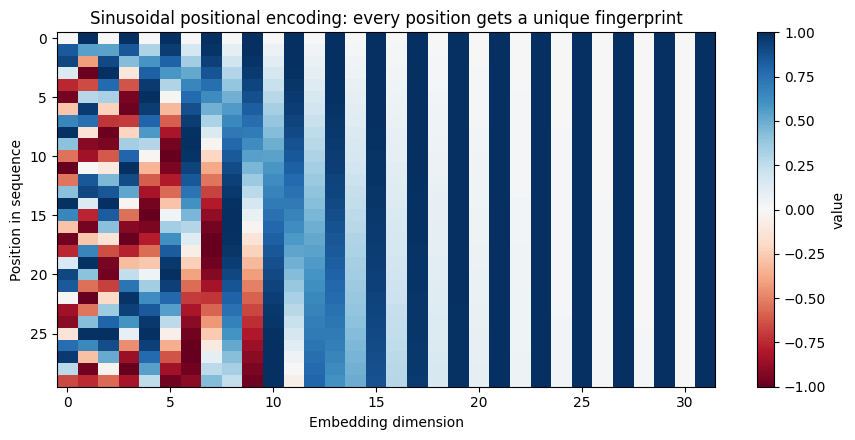

Cosine similarity of the two 'the' vectors WITHOUT positions: 1.000  (identical)
Cosine similarity of the two 'the' vectors WITH positions:    0.883  (now distinguishable)


In [5]:
# Positional encoding: give the transformer a sense of word ORDER.
# Attention alone treats a sentence as a bag of words; adding a unique sinusoidal
# "fingerprint" per position makes identical words at different places distinct.

def positional_encoding(seq_len, dim):
    pos = np.arange(seq_len)[:, None]                       # positions 0..seq_len-1
    i = np.arange(dim)[None, :]                             # dimensions 0..dim-1
    angle = pos / np.power(10000, (2 * (i // 2)) / dim)
    pe = np.zeros((seq_len, dim))
    pe[:, 0::2] = np.sin(angle[:, 0::2])                    # even dims: sine
    pe[:, 1::2] = np.cos(angle[:, 1::2])                    # odd dims: cosine
    return pe

# Visualize the fingerprint pattern for 30 positions x 32 dimensions
pe_big = positional_encoding(30, 32)
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(pe_big, cmap="RdBu", aspect="auto", vmin=-1, vmax=1)
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Position in sequence")
ax.set_title("Sinusoidal positional encoding: every position gets a unique fingerprint")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()

# The two "the" tokens: identical without positions, distinct with them
def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

pe = positional_encoding(len(words), d)
E_pos = E + pe                       # what actually enters a transformer's attention layer

first_the, second_the = 0, 3         # positions of the two "the" tokens
print(f"Cosine similarity of the two 'the' vectors WITHOUT positions: "
      f"{cosine(E[first_the], E[second_the]):.3f}  (identical)")
print(f"Cosine similarity of the two 'the' vectors WITH positions:    "
      f"{cosine(E_pos[first_the], E_pos[second_the]):.3f}  (now distinguishable)")

## Part 6: Causal Masking — the Difference Between BERT and GPT

One last mechanism, and it explains the two model families you will use next:

- **BERT-style (encoder)**: every word may attend to **every** word — left and right context. Great for
  *understanding* tasks: classification, named entity recognition, question answering.
- **GPT-style (decoder)**: a word may only attend to **itself and earlier words**. That is enforced with a
  **causal mask** (the upper-right triangle of the score matrix is blocked before the softmax). This is what
  makes left-to-right *generation* possible: the model never peeks at the future it is about to write.


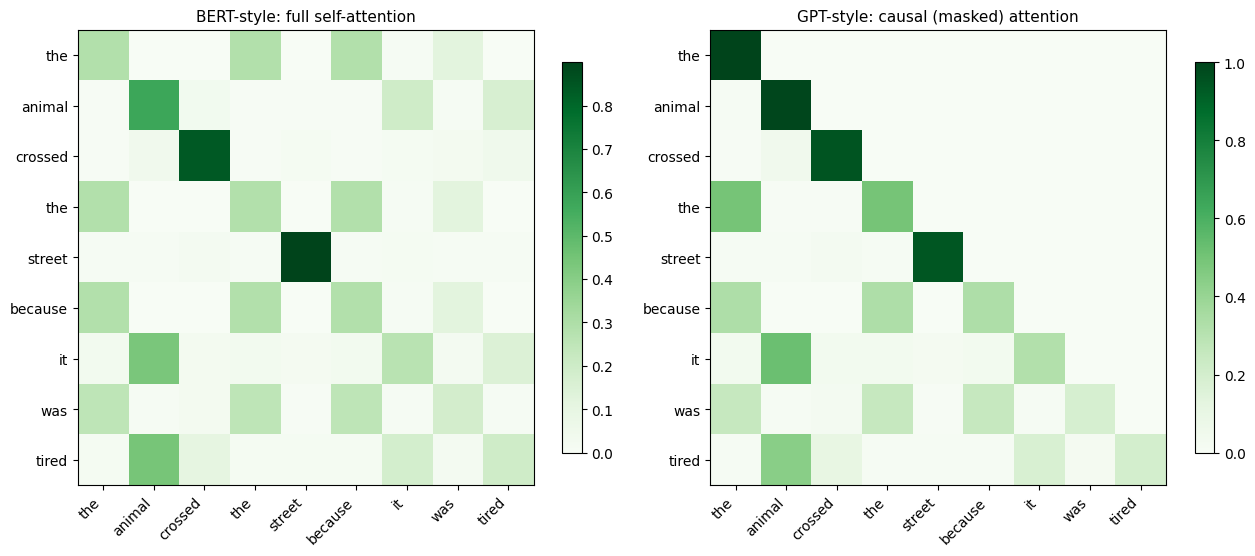

Causal rows still sum to 1: True
Attention 'it' -> 'was' (a FUTURE word), unmasked: 0.024
Attention 'it' -> 'was' (a FUTURE word), causal:   0.000

The causal map is lower-triangular: each word only sees itself and the past.


In [6]:
# BERT vs GPT in one picture: full self-attention vs causal (left-to-right) attention.
# A generator must not peek at the future words it is about to predict —
# the causal mask enforces that.

# Causal mask: block attention to future positions (set scores to -inf before softmax)
n = len(words)
mask = np.triu(np.ones((n, n), dtype=bool), k=1)      # True above the diagonal = "future"
masked_scores = np.where(mask, -np.inf, scores)
causal_attn = softmax(masked_scores, axis=1)

# Compare the two attention maps side by side: full vs lower-triangular.
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, (title, A) in zip(axes, [("BERT-style: full self-attention", attn),
                                 ("GPT-style: causal (masked) attention", causal_attn)]):
    im = ax.imshow(A, cmap="Greens", vmin=0)
    ax.set_xticks(range(n), words, rotation=45, ha="right")
    ax.set_yticks(range(n), words)
    ax.set_title(title, fontsize=11)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

print(f"Causal rows still sum to 1: {np.allclose(causal_attn.sum(axis=1), 1.0)}")
print(f"Attention 'it' -> 'was' (a FUTURE word), unmasked: {attn[6, 7]:.3f}")
print(f"Attention 'it' -> 'was' (a FUTURE word), causal:   {causal_attn[6, 7]:.3f}")
print("\nThe causal map is lower-triangular: each word only sees itself and the past.")

## 💬 Discuss

Everything here is arguable from the maps you just computed. None of it has a single right answer.

1. Your heatmap says `'it'` gave **43.3%** of its attention to `animal`. A stakeholder reads that as "the
   model decided *it* means the animal — here is the proof". Jain & Wallace tested that reading and called
   the result *Attention is not Explanation*
   ([arXiv:1902.10186](https://arxiv.org/abs/1902.10186)): attention weights often fail to correlate with
   gradient-based importance, and very different attention distributions can produce **identical**
   predictions. Wiegreffe & Pinter pushed back in *Attention is not not Explanation*
   ([arXiv:1908.04626](https://arxiv.org/abs/1908.04626)). Where do you stand, and what evidence would move
   you? Remember our weights came from hand-crafted vectors, not from learning.
2. Head A said `'it' → animal` (60.3%); Head B said `'it' → the` (19.0%). Two heads, two answers, one
   sentence. If you had to show a client exactly one of those numbers, which do you show — and what does
   that choice cost you in honesty?
3. Attention compares every word with every other word: 9 words gave a 9×9 = 81-weight matrix; a
   1,000-token contract gives 1,000,000. A colleague proposes simply truncating every document to the first
   512 tokens. For which of these is that acceptable and for which is it negligent — a tweet, a CV, a lease
   agreement, a hospital discharge summary? Justify each one separately.

## Part 7: From Attention to Transformers

You have now computed, by hand, the core mechanism. A **transformer** wraps it in a repeatable block:

```
one transformer block = multi-head self-attention  ->  small feed-forward network
                        (+ residual connections and normalization to keep training stable)
```

Stack that block 12–96 times, feed in word vectors + positional encodings, train the whole thing on
enormous amounts of text, and you get the models this unit uses:

| Model | Architecture | Sees | Pretrained for | Good at |
|-------|-------------|------|----------------|---------|
| **BERT** | encoder stack | both directions | fill-in-the-blank | understanding: classification, NER, QA |
| **GPT** | decoder stack (causal mask) | left context only | predict the next token | generation: writing, chat, code |

**Pretraining and fine-tuning.** Nobody in this course trains a transformer from scratch — that costs
millions of GPU-hours. Instead we download **pretrained** models (Hugging Face) and either use them as-is or
**fine-tune** them: continue training briefly on a small labeled dataset for our own task.

### Your roadmap for the rest of this unit

1. **`02_rnn_lstm_nlp.ipynb`** — the pre-transformer sequence models (RNNs/LSTMs) and the bottleneck that motivated attention
2. **`03_bert_advanced_usage.ipynb`** — use a pretrained BERT-family model for sentiment classification; see the fine-tuning recipe
3. **`04_seq2seq_attention_translation.ipynb`** — build (in Keras) the encoder–decoder-with-attention architecture where attention was born
4. **`05_gpt_openai_text_generation.ipynb`** — generate text with a real local GPT-2 model, and see how APIs scale it up

---

## ✅ Summary

- **Attention** = weighted average of word vectors, weights from `softmax(Q·Kᵀ/√d)` — you computed it in NumPy
- **Attention maps** show who attends to whom; in our toy sentence, *"it"* attends to *"animal"* (see the computed output above)
- **Multiple heads** capture different relationship types in parallel
- **Positional encodings** restore word order to an otherwise order-blind mechanism
- **Causal masking** is the single change that separates GPT-style generators from BERT-style encoders
- **Transformers** stack attention + feed-forward blocks; we use them **pretrained**

Everything in this notebook ran for real in NumPy. The word vectors were hand-crafted for readability —
real transformers *learn* theirs. How that learning works (backpropagation, optimizers, building
transformers yourself) is the subject of **AIAT 122 (Course 08, Deep Learning)**.


## ⚠️ Where this breaks

**Cost grows with the square of the length.** You built a 9×9 matrix — 81 weights. Attention builds `n × n`
weights for `n` tokens, so ten times the text is a hundred times the attention work and memory. That single
fact drives most of modern LLM engineering: context-length limits, FlashAttention's IO-aware rewrite
([arXiv:2205.14135](https://arxiv.org/abs/2205.14135)), paged KV caches
([arXiv:2309.06180](https://arxiv.org/abs/2309.06180)) and the whole efficient-transformer literature
([arXiv:2009.06732](https://arxiv.org/abs/2009.06732)).

**Attention weights are not explanations** — see the discussion above. Read a heatmap as *where the
computation routed information*, never as *why the model answered as it did*.

**Our numbers are illustrative, not learned.** We used the embeddings directly as Q, K and V. A real
transformer applies three *learned* projections first, and real attention maps look nothing like the tidy
diagonal-plus-pronoun picture here. The mechanism is genuine; the readability is a teaching artefact, and
the hand-crafted "animal-ness" dimension is what made `it → animal` come out so cleanly.

**When attention is the wrong tool:**
- Short, keyword-driven, high-volume classification (spam, ticket routing) → TF-IDF plus a linear model
  (Unit 3) is orders of magnitude cheaper to serve and often just as accurate.
- Streaming input, or very long sequences on a CPU with a latency budget → recurrent and state-space models
  such as Mamba ([arXiv:2312.00752](https://arxiv.org/abs/2312.00752)) cost linear time, not quadratic.
- You must produce an auditable decision trail for a regulator → a transformer plus a heatmap will not
  satisfy them; a rule set or a linear model with inspectable weights might.

## 📚 References

Where attention came from — and where it went:

1. Bahdanau, D., Cho, K., & Bengio, Y. (2015). *Neural Machine Translation by Jointly Learning to Align and Translate*. ICLR 2015. [arXiv:1409.0473](https://arxiv.org/abs/1409.0473)
2. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need*. NeurIPS 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
3. Tay, Y., Dehghani, M., Bahri, D., & Metzler, D. (2020). *Efficient Transformers: A Survey*. ACM Computing Surveys. [arXiv:2009.06732](https://arxiv.org/abs/2009.06732)
